# P5 — the cyclic attractors between Proliferation, Apoptosis and Autophagy

Phenotype class **P5** in `00_analysis_boolean_core.ipynb` has 4 attractors in which `Proliferation`,
`Apoptosis` and `Autop_digestion` are all free. These are *cyclic* attractors. This notebook asks
what drives the cycle and in what order the phenotypes switch.

1. **Full model.** Measure the attractors and project them onto the three readouts. Both results are exact.
2. **Feedback loops.** List every feedback loop of the network that runs inside P5, and show that
   everything else is feedforward chains.
3. **Reduced model.** Inline those chains so only the core loop and the readouts remain. The state
   transition graph (STG) of that small network can be drawn completely.
4. **Concatenated dynamics.** Run one asynchronous trajectory of the full model inside a P5 attractor.

In [1]:
%matplotlib inline
import itertools
import os
from pathlib import Path

import biobalm
import biodivine_aeon as ba
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import sympy
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sympy.logic.boolalg import simplify_logic

if not Path("model").exists():          # repo root, as in 00_analysis_boolean_core.ipynb
    os.chdir("../../../../")
plt.rcParams["figure.dpi"] = 150

BNET_PATH = Path("model/autophagy_september26/Autophagy_and_apoptosis_Sept26.bnet")
INPUTS = ["O_stress", "Growth_factor", "TNF_R_or_DR", "AA_Starvation", "Insuline",
          "Glucose_starv", "KEAP1", "NQO1"]
READOUTS = ["Proliferation", "Autop_digestion", "Apoptosis"]

## 1 — The P5 attractors in the full model

P5 = the attractors in which all three readouts are free. Each one is a minimal trap space of
`biobalm`. `biobalm` gives one seed state per attractor. Starting from the seed, the set of
states reachable asynchronously is the attractor itself, and AEON computes that set symbolically.

In [2]:
sd = biobalm.SuccessionDiagram.from_file(str(BNET_PATH))
sd.build()
names = sd.network.variable_names()

p5 = [n for n in sd.minimal_trap_spaces()
      if not any(r in sd.node_data(n)["space"] for r in READOUTS)]
assert len(p5) == 4

graph = ba.AsynchronousGraph(sd.network)
attractors = {n: ba.Reachability.reach_fwd(
                  graph, graph.mk_subspace(sd.node_attractor_seeds(n, compute=True)[0]))
              for n in p5}
labels = {n: f"P5.{k + 1}" for k, n in enumerate(p5)}

pd.DataFrame(
    [{**{i: sd.node_data(n)["space"][i] for i in INPUTS},
      "free nodes": len(names) - len(sd.node_data(n)["space"]),
      "attractor states": f"{attractors[n].cardinality():.1e}"} for n in p5],
    index=list(labels.values()),
)

,O_stress,Growth_factor,TNF_R_or_DR,AA_Starvation,Insuline,Glucose_starv,KEAP1,NQO1,free nodes,attractor states
P5.1,0,0,1,0,0,0,0,0,49,5.1e+14
P5.2,0,0,1,0,1,0,0,0,50,1.0e+15
P5.3,0,0,0,0,0,0,0,0,53,8.2e+15
P5.4,0,0,0,0,1,0,0,0,54,1.6e+16


Only `TNF_R_or_DR` and `Insuline` vary across the four attractors. Each attractor has
$10^{14}$–$10^{16}$ states, so its STG cannot be drawn.

The STG *can* be collapsed onto the three readouts. Below: the fraction of attractor states
that show each readout pattern, and the readouts that can flip from that pattern in a single
asynchronous step. Both are computed exactly from the full model.

In [3]:
def readout_projection(att):
    total = att.cardinality()
    rows = []
    for pattern in itertools.product([0, 1], repeat=len(READOUTS)):
        part = att.intersect(graph.mk_subspace(dict(zip(READOUTS, pattern))))
        rows.append({**dict(zip(READOUTS, pattern)),
                     "fraction of states": part.cardinality() / total,
                     "can flip": ", ".join(r for r in READOUTS
                                           if not graph.var_post(r, part).is_empty())})
    return pd.DataFrame(rows)

projections = {labels[n]: readout_projection(attractors[n]) for n in p5}
assert all(p.equals(projections["P5.1"]) for p in projections.values())   # same in all four
projections["P5.1"]

,Proliferation,Autop_digestion,Apoptosis,fraction of states,can flip
0,0,0,0,0.125,"Proliferation, Autop_digestion, Apoptosis"
1,0,0,1,0.125,"Proliferation, Autop_digestion, Apoptosis"
2,0,1,0,0.125,"Proliferation, Autop_digestion, Apoptosis"
3,0,1,1,0.125,"Proliferation, Autop_digestion, Apoptosis"
4,1,0,0,0.125,"Proliferation, Autop_digestion, Apoptosis"
5,1,0,1,0.125,"Proliferation, Autop_digestion, Apoptosis"
6,1,1,0,0.125,"Proliferation, Autop_digestion, Apoptosis"
7,1,1,1,0.125,"Proliferation, Autop_digestion, Apoptosis"


In the full model, all 8 readout combinations occur, each in exactly 1/8 of the states, and any
readout can flip from any combination. **At the phenotype level the attractor is a complete
cube.** The three phenotypes oscillate, but asynchronous updating along the long cascades that
lead to each readout lets them drift out of phase. To see *why* they oscillate, look at the
upstream mechanism.

## 2 — Feedback loop structure inside P5

Every value that the trap space fixes is set as a constant and propagated through the rules. What
remains is the network of the nodes that actually move inside the attractor. Then every
elementary feedback loop is listed with its sign (the product of its edge signs).

A **negative** loop is necessary for sustained oscillation, and a **positive** loop for
multistability (Thomas' rules). Any node on no loop only relays a signal downstream.

In [4]:
def percolate(n):
    # Network of the nodes that are free in trap space n (every fixed node is inlined as a constant)
    bn = ba.BooleanNetwork.from_file(str(BNET_PATH))
    for name, value in sd.node_data(n)["space"].items():
        bn.set_update_function(name, "true" if value else "false")
    return bn.inline_constants(infer_constants=True, repair_graph=True)

def signed_graph(bn):
    g = nx.DiGraph()
    g.add_nodes_from(bn.variable_names())
    for r in bn.regulations():
        g.add_edge(bn.get_variable_name(r["source"]), bn.get_variable_name(r["target"]),
                   sign=str(r["sign"]))
    return g

def loop_sign(g, loop):
    return "-" if sum(g[a][b]["sign"] == "-" for a, b in zip(loop, loop[1:] + loop[:1])) % 2 else "+"

def module(g, loop):
    if loop_sign(g, loop) == "+":
        return "autophagy / apoptosis crosstalk"
    return "AMPK-ULK1-MTOR oscillator" if "PRKA" in loop else "mitophagy"

free_net = {labels[n]: percolate(n) for n in p5}
free_graph = {k: signed_graph(bn) for k, bn in free_net.items()}
loops = {k: list(nx.simple_cycles(g)) for k, g in free_graph.items()}

# The loop structure is the same in all four attractors; they differ only by a few feedforward nodes
loop_sets = [{(frozenset(c), loop_sign(free_graph[k], c)) for c in loops[k]} for k in loops]
assert all(s == loop_sets[0] for s in loop_sets)

g, cycles = free_graph["P5.1"], loops["P5.1"]

def signed_path(path):
    return path[0] + "".join((" → " if g[a][b]["sign"] == "+" else " ⊣ ") + b
                             for a, b in zip(path, path[1:]))

def loop_string(loop):
    start = next((h for h in ["PRKA", "MOMP", "BECN1", "PIK3C3"] if h in loop), loop[0])
    i = loop.index(start)
    return signed_path(loop[i:] + loop[:i] + [start])

loop_table = pd.DataFrame([{"module": module(g, c), "sign": loop_sign(g, c), "length": len(c),
                            "loop": loop_string(c)} for c in cycles])
summary = loop_table.groupby(["module", "sign"]).agg(
    loops=("length", "size"), lengths=("length", lambda x: f"{x.min()}–{x.max()}"))
summary["nodes"] = [len(set().union(*(set(c) for c in cycles if module(g, c) == m))) for m, _ in summary.index]
print(f"P5.1: {g.number_of_nodes()} free nodes, {g.number_of_edges()} edges, {len(cycles)} feedback loops")
summary

P5.1: 49 free nodes, 69 edges, 38 feedback loops


,,loops,lengths,nodes
module,sign,,,
AMPK-ULK1-MTOR oscillator,-,4,2–6,7
autophagy / apoptosis crosstalk,+,33,2–16,20
mitophagy,-,1,3–3,3


In [5]:
pd.set_option("display.max_colwidth", None)
loop_table[loop_table["sign"] == "-"].sort_values("length")   # the five negative loops

,module,sign,length,loop
3,AMPK-ULK1-MTOR oscillator,-,2,PRKA → ULK1 ⊣ PRKA
37,mitophagy,-,3,MOMP → PINK1 → PARK2 ⊣ MOMP
0,AMPK-ULK1-MTOR oscillator,-,4,PRKA ⊣ RPTOR → MTOR ⊣ ULK1 ⊣ PRKA
2,AMPK-ULK1-MTOR oscillator,-,5,PRKA → TSC2 ⊣ RHEB → MTOR ⊣ ULK1 ⊣ PRKA
1,AMPK-ULK1-MTOR oscillator,-,6,PRKA → TSC2 ⊣ RHEB ⊣ FKBP8 ⊣ MTOR ⊣ ULK1 ⊣ PRKA


* **Oscillator.** All four negative loops through `PRKA` sit in one 7-node strongly connected
  component: `PRKA → ULK1 ⊣ PRKA`, plus three longer versions through MTOR (`RPTOR`, `TSC2`,
  `RHEB`, `FKBP8`).
* **Mitophagy.** The only other negative loop is `MOMP → PINK1 → PARK2 ⊣ MOMP`.
* **Crosstalk.** Every positive loop except `PIK3C3 ↔ UVRAG` goes through both `BECN1` and
  `Caspase_3_6_7_C`. These loops are the autophagy cascade and the apoptosis cascade joined
  head-to-tail by two inhibitions, `Atphgo_mat ⊣ MOMP` and `Caspase_3_6_7_C ⊣ BECN1`: a long
  mutual-inhibition loop.
* **Feedforward.** No loop feeds back from the branches to the oscillator, so the oscillator is
  the upstream driver. Every other node, the three readouts included, lies on no loop at all.

In the network below (top to bottom = upstream to downstream), each dashed box is one loop module, and grey nodes and edges are feedforward
only. A flat arrowhead is an inhibition; a square node is a readout.

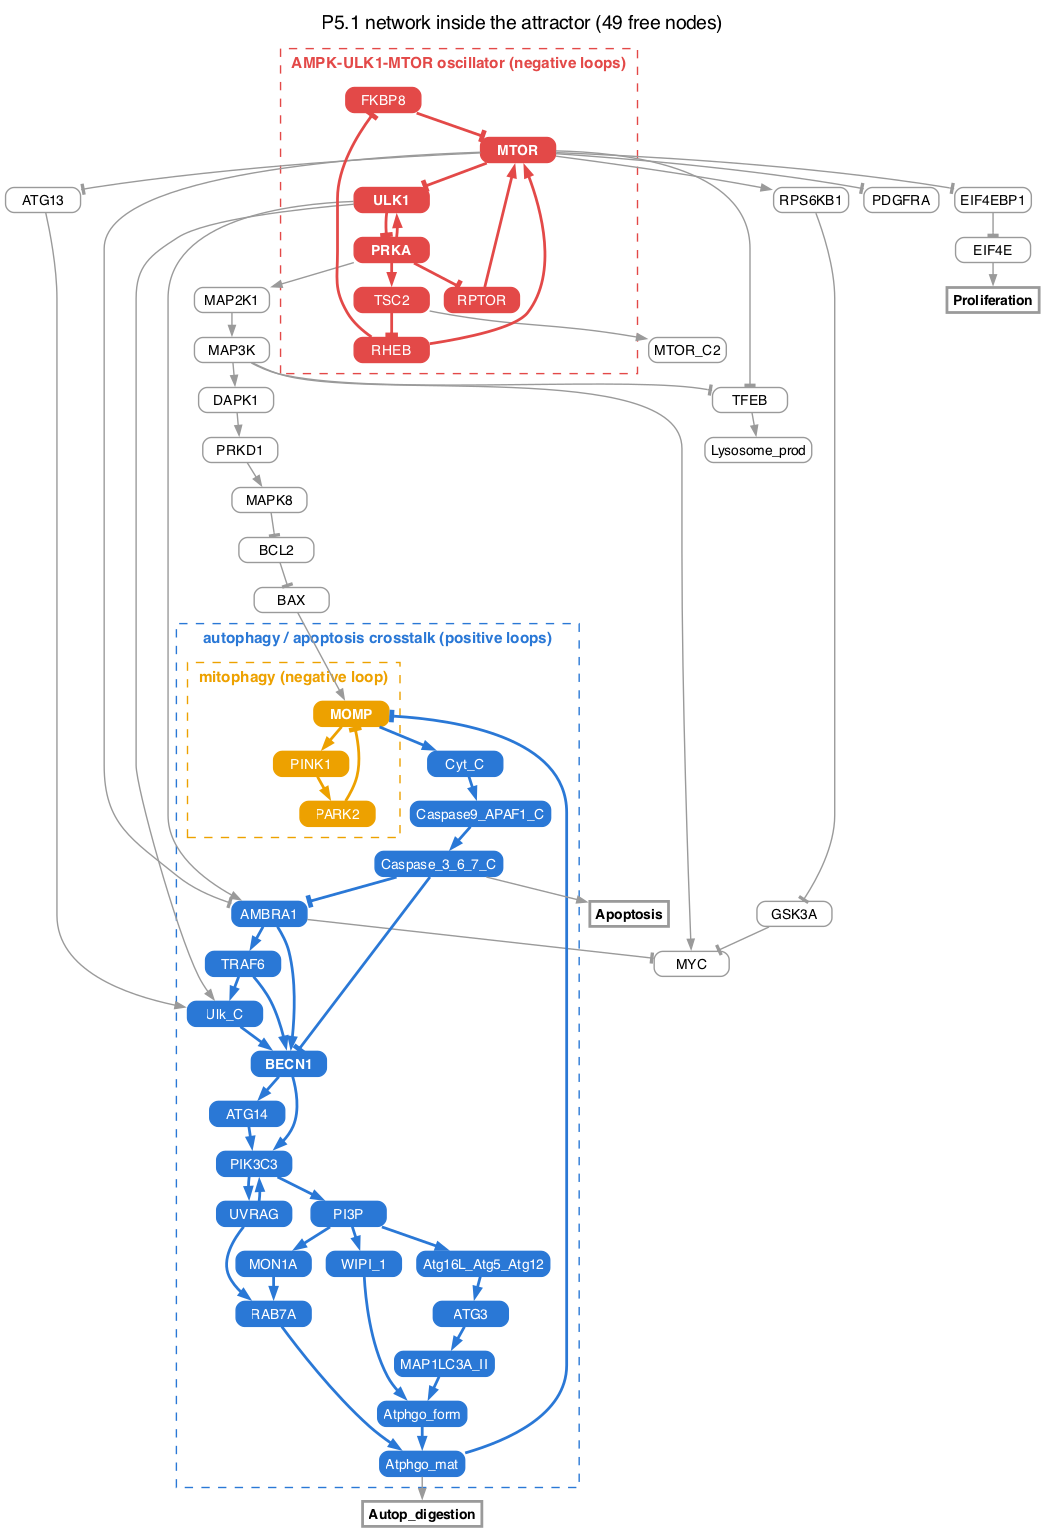

In [6]:
from IPython.display import Image
import pygraphviz as pgv

MODULE_COLOR = {"AMPK-ULK1-MTOR oscillator": "#e34948", "mitophagy": "#eda100",
                "autophagy / apoptosis crosstalk": "#2a78d6", "feedforward": "#9a9a9a"}

node_module, edge_module = {}, {}
for c in sorted(cycles, key=lambda c: module(g, c) == "autophagy / apoptosis crosstalk"):
    m = module(g, c)                       # negative-loop modules take precedence over crosstalk
    for a, b in zip(c, c[1:] + c[:1]):
        node_module.setdefault(a, m)
        edge_module.setdefault((a, b), m)
node_module = {v: node_module.get(v, "feedforward") for v in g}
edge_module = {e: edge_module.get(e, "feedforward") for e in g.edges}

A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.15", ranksep="0.25", fontname="Helvetica",
               label=f"P5.1 network inside the attractor ({g.number_of_nodes()} free nodes)", labelloc="t")
A.node_attr.update(shape="box", style="rounded,filled", fontname="Helvetica", fontsize="10",
                   height="0.25", margin="0.06,0.02")
for v in g:
    m = node_module[v]
    A.add_node(v, fillcolor="white" if m == "feedforward" else MODULE_COLOR[m],
               color=MODULE_COLOR[m], fontcolor="black" if m == "feedforward" else "white",
               fontname="Helvetica-Bold" if v in READOUTS + ["PRKA", "ULK1", "MTOR", "BECN1", "MOMP"] else "Helvetica",
               style="filled" if v in READOUTS else "rounded,filled", penwidth="2" if v in READOUTS else "1")
for (a, b), m in edge_module.items():
    A.add_edge(a, b, color=MODULE_COLOR[m], penwidth="2" if m != "feedforward" else "1",
               arrowhead="normal" if g[a][b]["sign"] == "+" else "tee", arrowsize="0.7")

def members(*mods):
    return [v for v in g if node_module[v] in mods]
cluster = dict(style="dashed", fontname="Helvetica-Bold", fontsize="11")
A.add_subgraph(members("AMPK-ULK1-MTOR oscillator"), name="cluster_osc",
               label="AMPK-ULK1-MTOR oscillator (negative loops)",
               color=MODULE_COLOR["AMPK-ULK1-MTOR oscillator"], fontcolor=MODULE_COLOR["AMPK-ULK1-MTOR oscillator"], **cluster)
crosstalk = A.add_subgraph(members("autophagy / apoptosis crosstalk", "mitophagy"), name="cluster_cross",
                           label="autophagy / apoptosis crosstalk (positive loops)",
                           color=MODULE_COLOR["autophagy / apoptosis crosstalk"],
                           fontcolor=MODULE_COLOR["autophagy / apoptosis crosstalk"], **cluster)
crosstalk.add_subgraph(members("mitophagy"), name="cluster_mito", label="mitophagy (negative loop)",
                       color=MODULE_COLOR["mitophagy"], fontcolor=MODULE_COLOR["mitophagy"], **cluster)
Image(A.draw(format="png", prog="dot", args="-Gdpi=100"))

### Everything off the loops is a feedforward chain

Starting from every edge that leaves a loop module, follow the feedforward nodes until the path
re-enters a loop module or stops. Every feedforward node lies on one of the chains below.

In [7]:
feedforward = {v for v, m in node_module.items() if m == "feedforward"}
chains = []

def follow(path):
    for w in g.successors(path[-1]):
        if w in feedforward:
            follow(path + [w])
        else:
            chains.append(path + [w])      # re-enters a loop module
    if g.out_degree(path[-1]) == 0:
        chains.append(path)                # dead end (readouts are here)

for u in sorted(set(g) - feedforward):
    for w in sorted(g.successors(u)):
        if w in feedforward:
            follow([u, w])
assert feedforward <= set().union(*map(set, chains))

pd.DataFrame([{"chain": signed_path(c), "feedforward nodes": sum(v in feedforward for v in c),
               "ends": "dead end" if g.out_degree(c[-1]) == 0 else f"re-enters loop at {c[-1]}"}
              for c in chains]).sort_values(["ends", "feedforward nodes"], ascending=[False, False], ignore_index=True)

,chain,feedforward nodes,ends
0,MTOR ⊣ ATG13 → Ulk_C,1,re-enters loop at Ulk_C
1,PRKA → MAP2K1 → MAP3K → DAPK1 → PRKD1 → MAPK8 ⊣ BCL2 ⊣ BAX → MOMP,7,re-enters loop at MOMP
2,PRKA → MAP2K1 → MAP3K ⊣ TFEB → Lysosome_prod,4,dead end
3,MTOR ⊣ EIF4EBP1 ⊣ EIF4E → Proliferation,3,dead end
4,MTOR → RPS6KB1 ⊣ GSK3A ⊣ MYC,3,dead end
5,PRKA → MAP2K1 → MAP3K → MYC,3,dead end
6,MTOR ⊣ TFEB → Lysosome_prod,2,dead end
7,AMBRA1 ⊣ MYC,1,dead end
8,Atphgo_mat → Autop_digestion,1,dead end
9,Caspase_3_6_7_C → Apoptosis,1,dead end


Each readout's route from the oscillator combines these chains with one arm of the crosstalk loop:

* **`Proliferation`**: `MTOR ⊣ EIF4EBP1 ⊣ EIF4E → Proliferation`, 3 steps.
* **`Apoptosis`**: `PRKA → MAP2K1 → MAP3K → DAPK1 → PRKD1 → MAPK8 ⊣ BCL2 ⊣ BAX → MOMP`
  (7 feedforward nodes), then `MOMP → Cyt_C → Caspase9_APAF1_C → Caspase_3_6_7_C → Apoptosis`.
  12 steps in total.
* **`Autop_digestion`**: `ULK1 → AMBRA1 → BECN1 → PIK3C3 → PI3P → Atg16L_Atg5_Atg12 → ATG3 →
  MAP1LC3A_II → Atphgo_form → Atphgo_mat → Autop_digestion`, 10 or more steps. Its AND gates
  must all be satisfied at once: BECN1 needs AMBRA1, TRAF6 and Ulk_C, and Atphgo_mat needs RAB7A
  and Atphgo_form.

In the asynchronous model, these different lengths are the delays that desynchronise the three
readouts in section 1.

## 3 — Reduction to the oscillating core

Section 2 says what can be compressed. The oscillator's 7 nodes collapse onto `PRKA`, `ULK1` and
`MTOR`. Each branch is represented by its entry node, `BECN1` (autophagy) and `MOMP` (apoptosis),
which keeps the crosstalk and mitophagy loops. Every other node is a chain link and is inlined
(AEON `inline_variable`): its rule is substituted into its targets. Nodes with a self-loop cannot
be inlined; none remain here.

In [8]:
CORE = ["PRKA", "ULK1", "MTOR", "BECN1", "MOMP"]
KEEP = CORE + READOUTS

def reduce_network(bn, keep):
    reducible = True
    while reducible:
        reducible = False
        for v in bn.variable_names():
            if v in keep:
                continue
            try:
                bn = bn.inline_variable(v, repair_graph=True)
                reducible = True
                break
            except RuntimeError:    # self-regulated node: cannot be inlined
                pass
    return bn

def to_sympy(bn):
    sym = {v: sympy.Symbol(v) for v in bn.variable_names()}
    return {v: simplify_logic(sympy.sympify(str(bn.get_update_function(v)).replace("!", "~"),
                                            locals=sym), form="dnf")
            for v in bn.variable_names()}

reduced = {}
for k, bn in free_net.items():
    small = reduce_network(bn, KEEP)
    assert sorted(small.variable_names()) == sorted(KEEP)
    reduced[k] = to_sympy(small)

rules_table = pd.DataFrame({k: {v: str(f) for v, f in r.items()} for k, r in reduced.items()})
assert (rules_table.nunique(axis=1) == 1).all()   # identical core in all four attractors
rules_table[["P5.1"]].rename(columns={"P5.1": "reduced rule (all four P5 attractors)"})

,reduced rule (all four P5 attractors)
Apoptosis,MOMP
Autop_digestion,BECN1
BECN1,ULK1 & ~MOMP & ~MTOR
MOMP,(PRKA & ~BECN1) | (PRKA & ~MOMP)
MTOR,~PRKA
PRKA,~ULK1
Proliferation,MTOR
ULK1,PRKA & ~MTOR


The four attractors reduce to the **same 5-node core**, so `TNF_R_or_DR` and `Insuline` do not
affect the cycle. Each readout is a delayed copy of one core node:
`Proliferation ← MTOR`, `Autop_digestion ← BECN1`, `Apoptosis ← MOMP`.

* `PRKA → ULK1 ⊣ PRKA` is a **negative feedback loop**: AMPK activates ULK1 and ULK1 shuts AMPK
  off. With nothing upstream to hold it, this loop is the oscillator.
* `PRKA ⊣ MTOR ⊣ ULK1` is a second negative loop that times the switch between growth and autophagy.
* `BECN1` (autophagy) needs ULK1 ON and MTOR OFF. `MOMP` (apoptosis) follows AMPK through the
  MAP3K→JNK→BCL2⊣BAX cascade. The two branches inhibit each other: `MOMP ⊣ BECN1`, and
  `BECN1 ⊣ MOMP` via autophagic digestion and PARK2.

### STG of the core

The core has $2^5 = 32$ states. Its single attractor is drawn below. The **angle** is the state
of the PRKA/ULK1/MTOR clock, following the cycle clockwise. The **ring** is the state of the two
branches. Fill colour shows which readouts are ON; a black outline means MTOR, and so
`Proliferation`, is ON.

In [9]:
core_rules = reduced["P5.1"]
core_fns = {v: sympy.lambdify([sympy.Symbol(c) for c in CORE], core_rules[v], "math") for v in CORE}

stg = nx.DiGraph()
for state in itertools.product([0, 1], repeat=len(CORE)):
    stg.add_node(state)
    for i, v in enumerate(CORE):
        new = int(bool(core_fns[v](*state)))
        if new != state[i]:
            stg.add_edge(state, state[:i] + (new,) + state[i + 1:], flipped=v)

cond = nx.condensation(stg)
terminal = [cond.nodes[c]["members"] for c in cond if cond.out_degree(c) == 0]
assert len(terminal) == 1
att = stg.subgraph(terminal[0])
print(f"core STG: {stg.number_of_nodes()} states -> one cyclic attractor of "
      f"{att.number_of_nodes()} states, {att.number_of_edges()} transitions")

core STG: 32 states -> one cyclic attractor of 28 states, 67 transitions


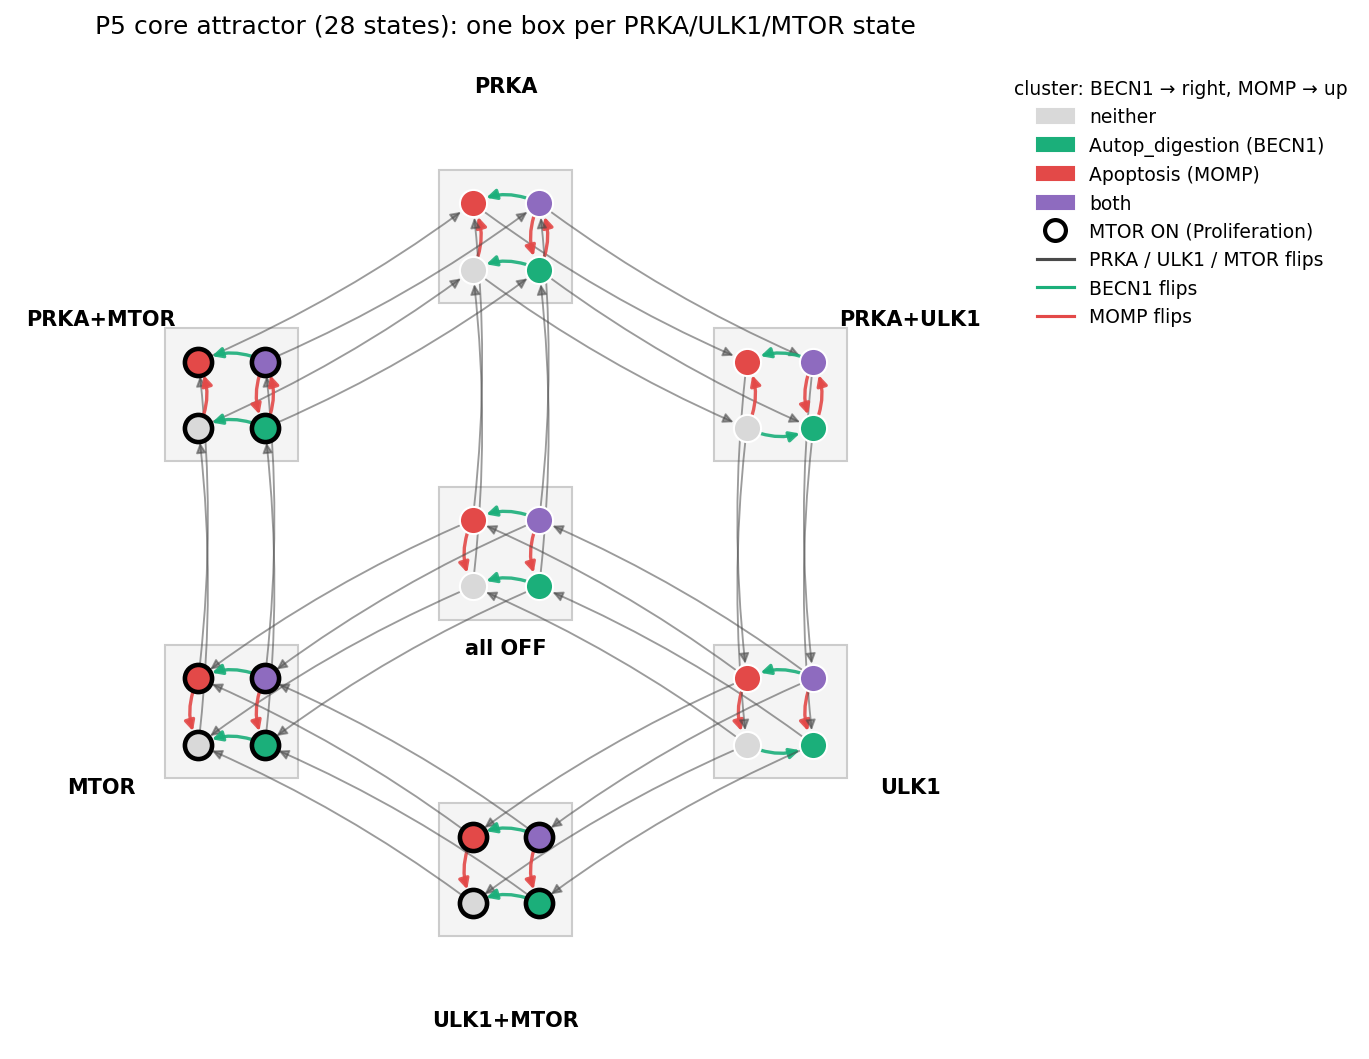

In [10]:
# Each clock state (PRKA, ULK1, MTOR) is a 2x2 cluster of branch states: BECN1 -> right, MOMP -> up.
# Clusters follow the cycle clockwise; "all OFF" (a branch point) sits in the centre.
RING = [(1, 0, 0), (1, 1, 0), (0, 1, 0), (0, 1, 1), (0, 0, 1), (1, 0, 1)]
CENTRE = (0, 0, 0)
BRANCH_COLOR = {(0, 0): "#d9d9d9", (1, 0): "#1baf7a", (0, 1): "#e34948", (1, 1): "#8e6bbf"}
BRANCH_LABEL = {(0, 0): "neither", (1, 0): "Autop_digestion (BECN1)",
                (0, 1): "Apoptosis (MOMP)", (1, 1): "both"}
FLIP_COLOR = {"PRKA": "#4a4a4a", "ULK1": "#4a4a4a", "MTOR": "#4a4a4a",
              "BECN1": "#1baf7a", "MOMP": "#e34948"}
assert {s[:3] for s in att} == set(RING) | {CENTRE}

def centre_of(clock):
    if clock == CENTRE:
        return np.zeros(2)
    theta = np.pi / 2 - 2 * np.pi * RING.index(clock) / len(RING)
    return 2.0 * np.array([np.cos(theta), np.sin(theta)])

pos = {s: centre_of(s[:3]) + 0.42 * (np.array(s[3:]) - 0.5) for s in att}

fig, ax = plt.subplots(figsize=(9, 8.5))
for clock in RING + [CENTRE]:
    c = centre_of(clock)
    ax.add_patch(plt.Rectangle(c - 0.42, 0.84, 0.84, fc="#f4f4f4", ec="#cccccc", zorder=0))
    label = "+".join(n for n, x in zip(CORE[:3], clock) if x) or "all OFF"
    offset = np.array([0, -0.6]) if clock == CENTRE else c / np.linalg.norm(c) * 0.95
    ax.text(*(c + offset), label, ha="center", va="center", fontsize=10, fontweight="bold")
for u, v, d in att.edges(data=True):
    branch = d["flipped"] in ("BECN1", "MOMP")
    ax.annotate("", xy=pos[v], xytext=pos[u],
                arrowprops=dict(arrowstyle="-|>", color=FLIP_COLOR[d["flipped"]],
                                lw=1.6 if branch else 0.9, alpha=0.9 if branch else 0.55,
                                shrinkA=7, shrinkB=7,
                                connectionstyle="arc3,rad=0.25" if branch else "arc3,rad=0.06"))
for s in att:
    ax.scatter(*pos[s], s=170, color=BRANCH_COLOR[s[3:]], zorder=3,
               edgecolors="black" if s[2] else "white", linewidths=2.2 if s[2] else 1.0)

ax.legend(handles=[Patch(color=BRANCH_COLOR[b], label=BRANCH_LABEL[b])
                   for b in [(0, 0), (1, 0), (0, 1), (1, 1)]]
          + [Line2D([], [], marker="o", ls="", mfc="white", mec="black", mew=2, ms=10,
                    label="MTOR ON (Proliferation)"),
             Line2D([], [], color=FLIP_COLOR["PRKA"], label="PRKA / ULK1 / MTOR flips"),
             Line2D([], [], color=FLIP_COLOR["BECN1"], label="BECN1 flips"),
             Line2D([], [], color=FLIP_COLOR["MOMP"], label="MOMP flips")],
          loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=9,
          title="cluster: BECN1 → right, MOMP → up", title_fontsize=9)
ax.set_title("P5 core attractor (28 states): one box per PRKA/ULK1/MTOR state", pad=14)
ax.set_xlim(-3.1, 3.1); ax.set_ylim(-3.1, 3.1)
ax.set_aspect("equal")
ax.set_axis_off()
plt.show()

Reading clockwise from the top:

1. **PRKA (AMPK) ON, MTOR OFF.** Proliferation is gone and AMPK drives `MOMP` (apoptosis) ON.
2. **PRKA + ULK1.** ULK1 activates while MTOR is OFF. `BECN1` is licensed, but only if MOMP is OFF.
3. **ULK1 alone.** ULK1 has switched AMPK off, so MOMP is no longer driven. This is the main
   autophagy window (`BECN1` ON).
4. **ULK1 + MTOR → MTOR.** With AMPK OFF, MTOR returns and blocks ULK1 and BECN1. Proliferation is back.
5. **PRKA + MTOR → PRKA.** AMPK re-activates (ULK1 is OFF), switches MTOR off, and the cycle restarts.
   From the centre (all OFF) AMPK can also return directly, skipping the proliferative phase.

The red and green edges inside each box show that the two branches only *follow* the clock: they
switch with a lag, and at some phases they can do so in either order. In every box with PRKA ON,
`MOMP` flips back and forth while `BECN1` is ON. This is the mitophagy loop:
MOMP → PINK1 → PARK2 ⊣ MOMP, which is active only when autophagosomes mature.

## 4 — Concatenated dynamics: one asynchronous trajectory of the full model

The reduction removes the cascades between the core and the readouts. A random asynchronous walk
on the **full model** restricted to `P5.1` (its 49 free nodes, section 2) puts the delays back. Starting from the
`biobalm` seed, at each step one node whose rule disagrees with its current value is picked
uniformly at random and updated.

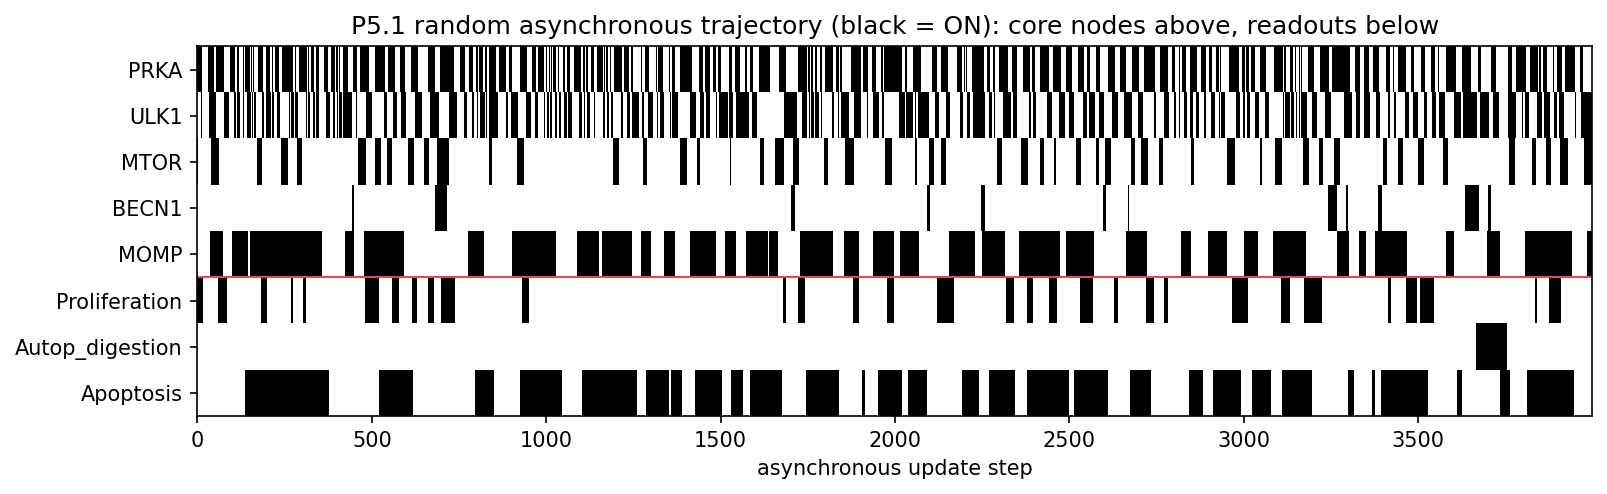

,PRKA,ULK1,MTOR,BECN1,MOMP,Proliferation,Autop_digestion,Apoptosis
fraction of steps ON,0.543,0.458,0.201,0.044,0.56,0.184,0.022,0.547


In [11]:
pnet = free_net["P5.1"]
pnodes = pnet.variable_names()
p_rules = to_sympy(pnet)
p_fns = [sympy.lambdify([sympy.Symbol(m) for m in pnodes], p_rules[v], "math") for v in pnodes]

rng = np.random.default_rng(0)
state = [int(sd.node_attractor_seeds(p5[0], compute=True)[0][v]) for v in pnodes]
TRACK = CORE + READOUTS
track_idx = [pnodes.index(v) for v in TRACK]
trace = []
for _ in range(4000):
    unstable = [i for i, f in enumerate(p_fns) if int(bool(f(*state))) != state[i]]
    i = rng.choice(unstable)
    state[i] = 1 - state[i]
    trace.append([state[j] for j in track_idx])
trace = np.array(trace).T

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.imshow(trace, aspect="auto", interpolation="nearest", cmap="Greys")
ax.set_yticks(range(len(TRACK)), TRACK)
ax.axhline(len(CORE) - 0.5, color="#e34948", lw=1)
ax.set_xlabel("asynchronous update step")
ax.set_title("P5.1 random asynchronous trajectory (black = ON): core nodes above, readouts below")
plt.show()

pd.DataFrame(trace.T, columns=TRACK).mean().rename("fraction of steps ON").round(3).to_frame().T

In the full model the readouts lag the core by the length of their cascades. `Proliferation`
tracks MTOR within a few steps. `Apoptosis` follows MOMP through the short caspase chain.
`Autop_digestion` is rarely reached: BECN1 has only a narrow window (ULK1 ON, MTOR OFF, MOMP OFF),
and the ~8-step chain from BECN1 to digestion is usually cut short by the next MTOR or MOMP phase.

**Summary**

* All four P5 attractors share one oscillator: the AMPK (`PRKA`)–ULK1 negative feedback loop,
  timed by MTOR. TNF and insulin play no part.
* The three phenotypes are outputs of that one clock, read at different phases:
  MTOR ON → proliferation; PRKA ON → MOMP and apoptosis; ULK1 ON with MTOR and MOMP OFF → autophagy.
* At the phenotype level, the full attractor is a complete cube: every combination of the three
  readouts is reachable. The ordered cycle exists in the core, and the cascades to each readout
  blur it.
* The core STG comes from a Naldi-style inlining reduction. Inlining removes intermediate delays,
  so read its ordering as the mechanism, not as timing. Sections 1, 2 and 4 are computed
  from the full model.